In [167]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Task 1

In [168]:
# Transitions matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0, 0.986, 0.005, 0.004, 0.005],
    [0, 0, 0.992, 0.003, 0.005],
    [0, 0, 0, 0.991, 0.009],
    [0, 0, 0, 0, 1]
])

# Parameters
n_states = len(P)
n_sims = 1000
states = np.arange(n_states)

# Array to store results
iters = np.zeros(n_sims)

# Random number generator
rng = np.random.default_rng(30)


local_reaccurance_count = 0
for i in range(n_sims):
    # Inital parameters
    iter = 0
    curr_state = 0
    local_reaccurance = 0

    # Transition to states until death
    while True:
        new_state = rng.choice(states, p=P[curr_state])
        
        # If state is the last state (death) then stop
        if new_state == (n_states-1):
            iters[i] = iter
            break

        if new_state == 1:
            local_reaccurance = 1
        
        # Update current state
        curr_state = new_state

        iter += 1 

    local_reaccurance_count += local_reaccurance

In [169]:
print(f"Propertion of women where the cancer reaccur locally: {local_reaccurance_count / n_sims}")

Propertion of women where the cancer reaccur locally: 0.573


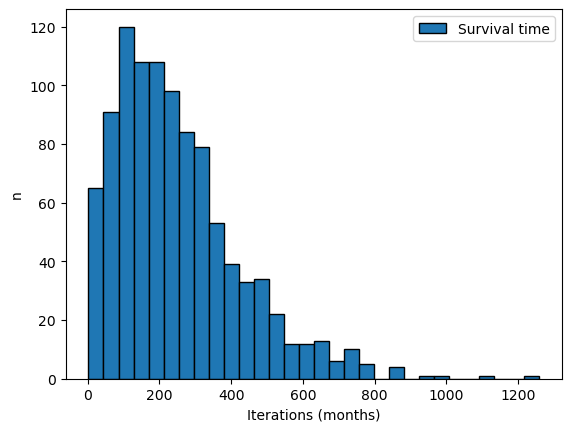

In [170]:
plt.hist(iters,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("Iterations (months)")
plt.legend()
plt.show()

# Task 2

In [171]:
# simulate
sims = np.zeros(n_sims, dtype=np.int64)
states = np.arange(n_states)
rng = np.random.default_rng(30)

T = 120

for i in range(n_sims):
    curr_state = 0

    for t in range(T):
        new_state = rng.choice(states, p=P[curr_state])
        curr_state = new_state
    
    sims[i] = curr_state

# Theoretical distr
p0 = np.array([1,0,0,0,0])
pt = p0@np.linalg.matrix_power(P,T)

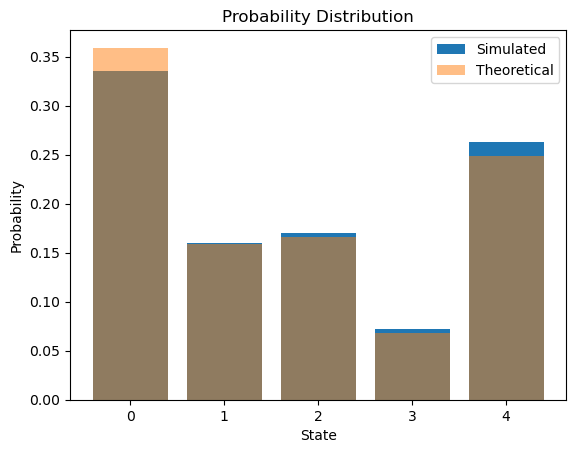

In [172]:
bin_count = np.bincount(sims, minlength=5) / len(sims)
plt.bar(states,bin_count, label="Simulated")
plt.bar(states, pt, label="Theoretical", alpha=0.5)
plt.xlabel("State")
plt.ylabel("Probability")
plt.title("Probability Distribution")
plt.xticks(states)
plt.legend()
plt.show()

# Task 3

In [173]:
# Transitions matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0, 0.986, 0.005, 0.004, 0.005],
    [0, 0, 0.992, 0.003, 0.005],
    [0, 0, 0, 0.991, 0.009],
    [0, 0, 0, 0, 1]
])

Ps = P[:-1, :-1]
ps = P[:-1, -1]
pi = np.array([1,0,0,0])

PT = lambda t: pi @ np.linalg.matrix_power(Ps, t) @ ps

ts = np.arange(0,1500,1)

PT_arr = np.zeros(len(ts))
for i in range(len(ts)):
    PT_arr[i] = PT(ts[i])

theoretical_lifetime = pi @ np.linalg.inv(np.eye(np.shape(Ps)[0]) - Ps) @ np.ones(np.shape(Ps)[0])

Estimated mean lifetime: 250.681
Theoretical mean lifetime: 262.3716153127931


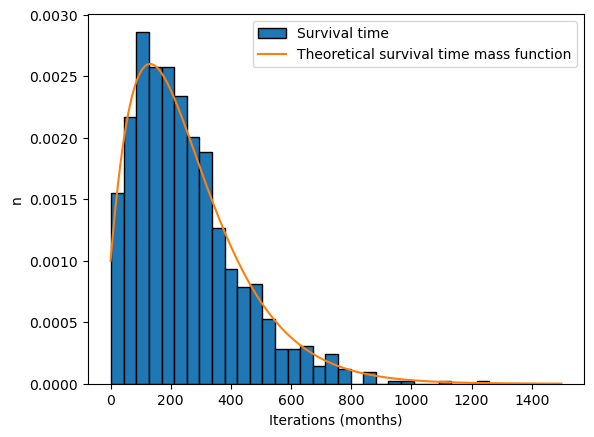

In [174]:
print(f'Estimated mean lifetime: {np.mean(iters)}')
print(f'Theoretical mean lifetime: {theoretical_lifetime}')
plt.hist(iters,bins=30, density=True, edgecolor="black", label="Survival time")
plt.plot(ts, PT_arr, label='Theoretical survival time mass function')
plt.ylabel("n")
plt.xlabel("Iterations (months)")
plt.legend()
plt.show()

# Task 4

In [175]:
# Transitions matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0, 0.986, 0.005, 0.004, 0.005],
    [0, 0, 0.992, 0.003, 0.005],
    [0, 0, 0, 0.991, 0.009],
    [0, 0, 0, 0, 1]
])

# Parameters
n_states = len(P)
accepted_sims = 0
states = np.arange(n_states)

# Array to store results
n_sims = 1000
sims = np.zeros(n_sims)

# Random number generator
rng = np.random.default_rng(30)

# Overall simulations required
iters = 0

# Run simulations until n_sims accepted simulations have been made
while (accepted_sims < n_sims):
    # Inital parameters
    curr_state = 0
    t = 0
    reappeared = False
    iters += 1

    # Transition to states until either it is rejected or death
    while True:
        # Simulate transistion
        new_state = rng.choice(states, p=P[curr_state])

        # Record if cancer has appeared
        if (new_state == 1 or new_state == 2 or new_state == 3):
            reappeared = True

        # If cancer has not reappeared and time is over 12 month, reject the simulation
        if (reappeared == False and t >= 12):
            break

        # If patient dies within 12 months, reject
        if (new_state == 4 and t < 12):
            break
        
        # Record the final time of death if simulation is accepted
        if (new_state == 4 and t >= 12):
            sims[accepted_sims] = t
            accepted_sims += 1
            break
        
        # Update current state
        curr_state = new_state

        # Update current time for simulation
        t += 1 

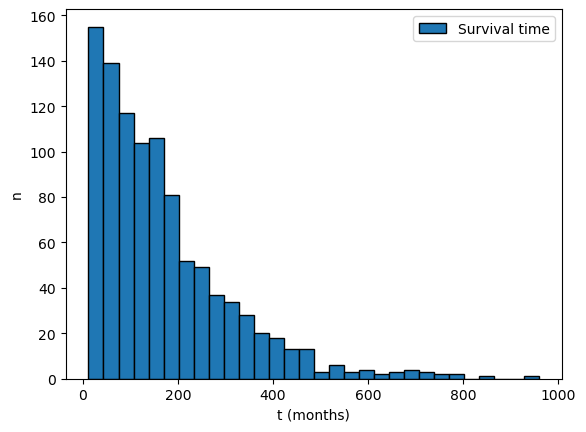

Expected lifetime: 169.037


In [176]:
plt.hist(sims,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("t (months)")
plt.legend()
plt.show()
print(f'Expected lifetime: {np.mean(sims)}')

# Task 5

### Crude simulation

In [177]:
# Transitions matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0, 0.986, 0.005, 0.004, 0.005],
    [0, 0, 0.992, 0.003, 0.005],
    [0, 0, 0, 0.991, 0.009],
    [0, 0, 0, 0, 1]
])

# Parameters
n_states = len(P)
n_sims = 200
n_iters = 100
states = np.arange(n_states)

# Array to store results
estimates = np.zeros(n_iters)

# Random number generator
rng = np.random.default_rng(30)

for j in range(n_iters):
    lifetimes = np.zeros(n_sims)

    for i in range(n_sims):
        # Inital parameters
        t = 0
        curr_state = 0

        # Transition to states until death
        while True:
            new_state = rng.choice(states, p=P[curr_state])
            
            # If state is the last state (death) then stop
            if (new_state == 4):
                lifetimes[i] = t
                break
            
            # Update current state
            curr_state = new_state

            t += 1 

    estimates[j] = np.sum(lifetimes <= 350)/n_sims

In [178]:
np.mean(estimates), np.var(estimates, ddof=1)

(0.74025, 0.0010729166666666678)

### Control variates

In [179]:
# Transitions matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0, 0.986, 0.005, 0.004, 0.005],
    [0, 0, 0.992, 0.003, 0.005],
    [0, 0, 0, 0.991, 0.009],
    [0, 0, 0, 0, 1]
])

# Parameters
n_states = len(P)
n_sims = 200
n_iters = 100
states = np.arange(n_states)

# Array to store results
X = np.zeros(n_iters)
Z = np.zeros(n_iters)

# Random number generator
rng = np.random.default_rng(30)

for j in range(n_iters):
    lifetimes = np.zeros(n_sims)

    for i in range(n_sims):
        # Inital parameters
        t = 0
        curr_state = 0

        # Transition to states until death
        while True:
            new_state = rng.choice(states, p=P[curr_state])
            
            # If state is the last state (death) then stop
            if (new_state == 4):
                lifetimes[i] = t
                break
            
            # Update current state
            curr_state = new_state

            t += 1

    Z[j] = np.mean(lifetimes) 
    X[j] = np.sum(lifetimes <= 350)/n_sims

In [180]:
c = -(np.cov(X,Z)[0,1])/(np.var(Z, ddof=1))
Y = X + c*(Z - theoretical_lifetime)
np.mean(Y), np.var(Y, ddof=1)

(0.7381255067153394, 0.0003513886526607451)